# Limpieza y análisis exploratorio del dataset de setas

## Configuración inicial e importación de librerías
En esta sección se cargan las librerías necesarias para la manipulación de datos, visualización y análisis estadístico.


In [29]:
# Manipulación y análisis de datos de estructura tabular
import pandas as pd
import numpy as np
# Visualización de datos (gráficos estáticos y estadísticos)
import matplotlib.pyplot as plt
import seaborn as sns
# Gestión de rutas de archivos de forma independiente del sistema operativo
from pathlib import Path
# Prueba estadística para evaluar la independencia entre variables categóricas
from scipy.stats import chi2_contingency

## Carga del dataset y exploración inicial
Lectura del archivo de datos y visualización de las primeras filas para entender la estructura del DataFrame.

In [30]:
# Definir la ruta raíz del proyecto (un nivel arriba del directorio actual)
BASE_DIR = Path().resolve().parent
# Construir la ruta exacta hacia el archivo de datos del dataset de hongos (Mushroom)
data_path = BASE_DIR / "data" / "agaricus-lepiota.data"
# Cargar el archivo CSV en un DataFrame de Pandas
df = pd.read_csv(data_path)
# Mostrar las primeras 5 filas del dataset para verificar la carga correcta
df.head()

,p,x,s,n,t,p.1,f,c,n.1,k,...,s.2,w,w.1,p.2,w.2,o,p.3,k.1,s.3,u
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


## Asignación de nombres a las columnas
Dado que el archivo original no contiene una fila de cabecera, se define manualmente la lista con los nombres descriptivos de cada característica (features) según la documentación del dataset para asignarlos al DataFrame.

In [31]:
# Lista ordenada con los nombres oficiales de las 23 columnas del dataset
columns = [
    "class",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat"
]
# Reemplazar los encabezados actuales del DataFrame por la lista de nombres descriptivos
df.columns = columns

> **Nota sobre la variable `odor` (olor):** 
> * `a`: almendra (almond) | `l`: anís (anise) | `c`: creosota (creosote) | `y`: pescado (fishy)
> * `f`: fétido/desagradable (foul) | `m`: mohoso (musty) | `n`: sin olor (none) 
> * `p`: picante/penetrante (pungent) | `s`: especiado (spicy)

## Verificación de la estructura con encabezados

In [32]:
# Comprobar visualmente que el DataFrame ahora cuenta con los encabezados asignados
df.head()
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g


## Inspección de Dimensiones y Tipos de Datos
En este bloque analizamos la volumetría del conjunto de datos (número de filas y columnas) junto con un resumen técnico de la estructura del DataFrame para validar la consistencia de los tipos de datos y la presencia de valores nulos.

In [33]:
# Obtener las dimensiones del dataset (registros, columnas)
# El resultado indica que contamos con 8,123 observaciones y 23 variables
df.shape

(8123, 23)

In [34]:
# Obtener un resumen del DataFrame: índices, tipos de datos por columna y conteo de valores no nulos
# Nota: Observamos que todas las variables son de tipo categórico (str/object) y preliminarmente no registran nulos aparentes.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8123 entries, 0 to 8122
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8123 non-null   str  
 1   cap-shape                 8123 non-null   str  
 2   cap-surface               8123 non-null   str  
 3   cap-color                 8123 non-null   str  
 4   bruises                   8123 non-null   str  
 5   odor                      8123 non-null   str  
 6   gill-attachment           8123 non-null   str  
 7   gill-spacing              8123 non-null   str  
 8   gill-size                 8123 non-null   str  
 9   gill-color                8123 non-null   str  
 10  stalk-shape               8123 non-null   str  
 11  stalk-root                8123 non-null   str  
 12  stalk-surface-above-ring  8123 non-null   str  
 13  stalk-surface-below-ring  8123 non-null   str  
 14  stalk-color-above-ring    8123 non-null   str  
 15

## Resumen Estadístico Descriptivo de Variables Categóricas
Generación del resumen estadístico para variables cualitativas. Esto permite identificar la cantidad de categorías únicas por columna, el valor modal (más común) y la frecuencia con la que aparece en el dataset.

In [35]:
# Mostrar estadísticas descriptivas de las columnas categóricas
# 'count': total de filas, 'unique': número de etiquetas diferentes, 'top': valor más común, 'freq': ocurrencias del top
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8123,8123,8123,8123,8123,8123,8123,8123,8123,8123,...,8123,8123,8123,8123,8123,8123,8123,8123,8123,8123
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3655,3244,2283,4748,3528,7913,6811,5612,1728,...,4935,4463,4383,8123,7923,7487,3967,2388,4040,3148


## Identificación de Valores Faltantes Ocultos
En este dataset, los valores nulos o desconocidos no vienen codificados como `NaN`, sino con el carácter `?`. Se realiza un conteo por columna para identificar la presencia de estos datos faltantes.

> **Hallazgo:** La variable `stalk-root` (raíz del tallo) presenta 2,480 registros con valores desconocidos, lo cual requerirá una estrategia de imputación o manejo de nulos más adelante.

In [36]:
# Contar cuántas celdas contienen el carácter "?" en cada columna del DataFrame
# .sum() suma las coincidencias booleanas (True = 1, False = 0) por columna
(df == "?").sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

## Estandarización y Validación de Valores Nulos
Reemplazo de los caracteres de interrogación (`?`) por valores nulos estándar reconocidos por NumPy (`np.nan`). Posteriormente, se vuelve a validar el dataset utilizando los métodos nativos de Pandas para asegurar que la conversión fue exitosa.

In [37]:
# Reemplazar el string "?" por el valor nulo oficial de NumPy (NaN) en todo el DataFrame
# Esto permite que Pandas reconozca formalmente las celdas vacías o faltantes
df = df.replace("?", np.nan)

In [38]:
# Validar el conteo de nulos usando el método nativo de Pandas
# Se confirma que 'stalk-root' contiene oficialmente los 2,480 valores NaN
df.isnull().sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

## Eliminación de Variables con Nulos y Control de Duplicados
Se procede con la eliminación de la columna con alta cantidad de valores faltantes para evitar sesgos en el análisis. Posteriormente, se realiza un control de calidad buscando registros completamente idénticos en el conjunto de datos.

> **Nota sobre la variable objetivo (`class`):**
> * `e`: Comestibles (edible)
> * `p`: Venenosos (poisonous)

In [39]:
# Eliminar definitivamente la columna 'stalk-root' debido a su alto volumen de valores nulos (NaN)
df = df.drop(columns=["stalk-root"])

In [40]:
# Contar la cantidad de registros duplicados en el DataFrame resultante
# El resultado de 0 confirma que todas las observaciones restantes son únicas
df.duplicated().sum()

np.int64(0)

## Filtro de Varianza Cero (Eliminación de Variables Constantes)
Identificación y remoción de variables constantes (con un único valor en todo el dataset). Al no presentar variabilidad entre los registros, estas columnas carecen de poder predictivo y no aportan información útil para el entrenamiento de los modelos de clasificación.

> **Resultado:** Se detectó que la columna `veil-type` contiene únicamente el valor `'p'` en todas las observaciones, por lo que fue descartada del DataFrame.

In [41]:
# Buscar mediante una lista de comprensión todas las columnas que tengan solo 1 valor único (.nunique() == 1)
columnas_inutiles = [col for col in df.columns if df[col].nunique() == 1]
# Imprimir en consola la lista de características detectadas sin varianza
print(f"Columnas que no aportan información: {columnas_inutiles}")
# 'veil-type' tiene un solo valor ('p'). Hay que eliminarla.
# Eliminar del DataFrame las columnas constantes identificadas para limpiar el set de datos
df = df.drop(columns=columnas_inutiles)

Columnas que no aportan información: ['veil-type']


## Análisis de Distribución de la Variable Objetivo
Exploración de la frecuencia de las categorías de la variable `class` (`e` = comestible, `p` = venenoso). Este paso permite verificar el balance de las clases para anticipar si se requerirán técnicas de remuestreo durante el modelado.

> **Diagnóstico:** El conjunto de datos se encuentra balanceado, con una distribución muy equitativa entre ambas etiquetas, lo que facilitará un entrenamiento estable del clasificador.

In [42]:
# Contar la cantidad de registros pertenecientes a cada clase (comestible vs venenoso)
# Permite evaluar visualmente el equilibrio de las clases en la variable objetivo
df["class"].value_counts()

class
e    4208
p    3915
Name: count, dtype: int64

## Análisis exploratorio de datos (EDA)
### Visualización de la Variable Objetivo
Se genera un gráfico de barras de frecuencias (`countplot`) y un cálculo porcentual para plasmar visualmente el equilibrio de la variable predictiva `class`. Esto valida de forma gráfica que el dataset no sufre de sesgos severos de clase.

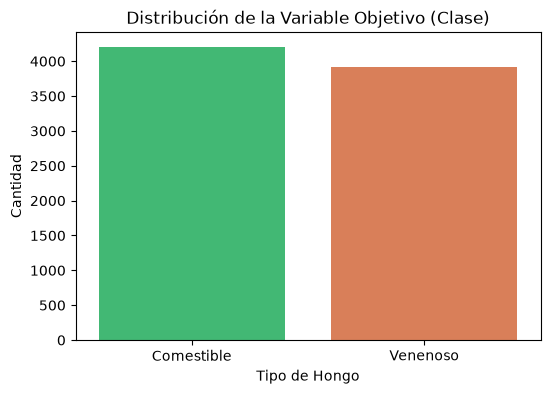

class
Comestible    51.803521
Venenoso      48.196479
Name: proportion, dtype: float64


In [43]:
# Definir el tamaño del lienzo de la gráfica (ancho, alto)
plt.figure(figsize=(6, 4))
# Crear gráfico de barras asignando colores personalizados para cada clase mediante una paleta
sns.countplot(data=df, x='class', hue='class', palette={'e': '#2ecc71', 'p': '#e74'})
# Configurar títulos y etiquetas descriptivas de los ejes
plt.title('Distribución de la Variable Objetivo (Clase)')
plt.xlabel('Tipo de Hongo')
plt.ylabel('Cantidad')
# Reemplazar las etiquetas del eje X por nombres completos para mejorar la lectura
plt.xticks([0, 1], ['Comestible', 'Venenoso']) # Set custom x-axis labels
# Desplegar la gráfica en el notebook
plt.show()
# --- Análisis Numérico Complementario ---
# Calcular la proporción relativa de cada clase convirtiéndola a formato de porcentaje (* 100)
class_counts = df['class'].value_counts(normalize=True) * 100
# Renombrar los índices para imprimir el reporte final con nombres claros
print(class_counts.rename(index={'e': 'Comestible', 'p': 'Venenoso'}))

### Análisis Bivariado: Relación entre el Olor y la Clase de Hongo
Se realiza un análisis bivariado cruzando la característica del olor con la clase de hongo mediante una tabla de contingencia. Las etiquetas originales se traducen al español para facilitar la interpretación del gráfico de barras apiladas, permitiendo observar visualmente si ciertos olores son determinantes para identificar hongos venenosos o comestibles.

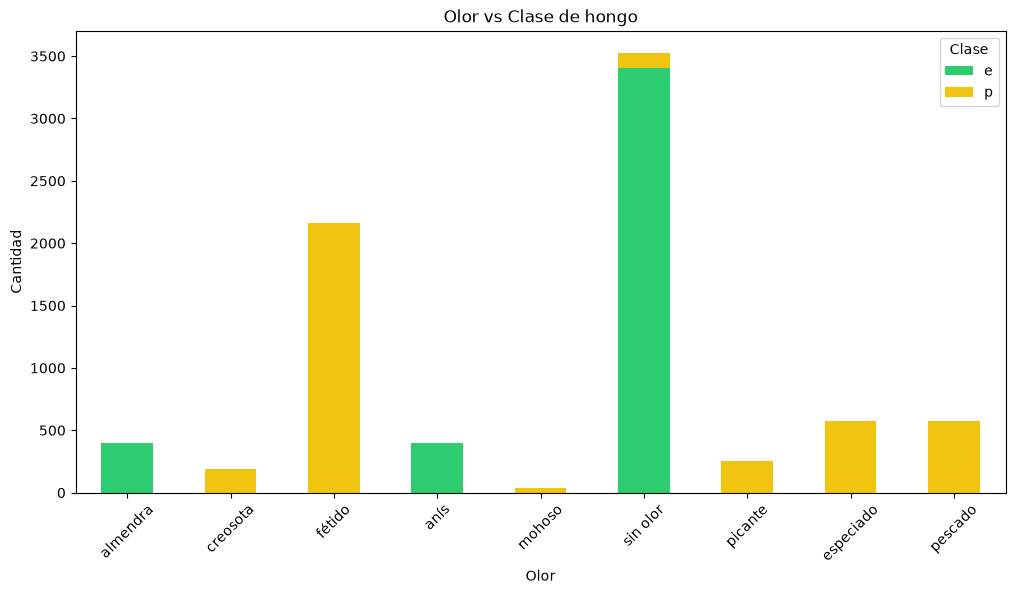

In [44]:
# Diccionario de mapeo para traducir las siglas de los olores a términos descriptivos en español
odor_map = {
    "a": "almendra",
    "l": "anís",
    "c": "creosota",
    "y": "pescado",
    "f": "fétido",
    "m": "mohoso",
    "n": "sin olor",
    "p": "picante",
    "s": "especiado"
}
# Crear una tabla de contingencia (frecuencias cruzadas) entre el olor y la clase del hongo
tabla = pd.crosstab(df["odor"], df["class"])
# Mapear y reemplazar los índices de la tabla (las letras) por los nombres descriptivos en español
tabla.index = tabla.index.map(odor_map)
# Generar un gráfico de barras apiladas con colores personalizados para cada clase
ax = tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#2ecc71", "#f1c40f"]
)
# Configurar las etiquetas de los ejes y el título del gráfico
ax.set_xlabel("Olor")
ax.set_ylabel("Cantidad")
plt.title("Olor vs Clase de hongo")
# Rotar los nombres del eje X a 45 grados para evitar que se superpongan y mejorar la lectura
plt.xticks(rotation=45)
# Añadir la leyenda explicativa para identificar las clases
plt.legend(title="Clase")
# Desplegar la visualización final
plt.show()



### Análisis Bivariado: Relación entre el Color de la Espora y la Clase de Hongo
Se analiza la influencia del color de la esporada en la toxicidad o comestibilidad del hongo. Para ello, se mapean los caracteres originales a sus nombres descriptivos en español de forma directa en el eje X de un gráfico de barras (`countplot`) agrupado por clases.

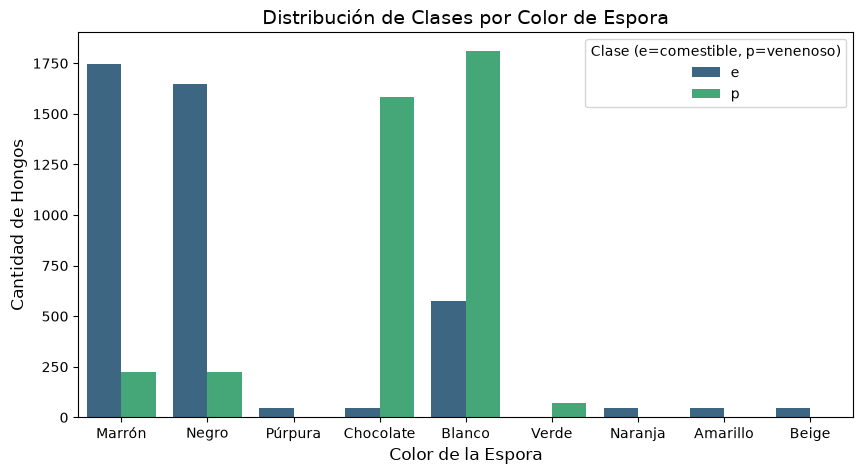

In [45]:
# Diccionario de traducción para convertir las abreviaturas de los colores de la espora a español
traduccion_espora = {
    'k': 'Negro', 'n': 'Marrón', 'b': 'Beige', 'h': 'Chocolate',
    'r': 'Verde', 'o': 'Naranja', 'u': 'Púrpura', 'w': 'Blanco', 'y': 'Amarillo'
}
# Configurar las dimensiones del lienzo del gráfico
plt.figure(figsize=(10, 5))
# Generar el gráfico de barras aplicando la traducción al eje X sin modificar el DataFrame original
# Se desglosa la visualización por clase utilizando la paleta de colores 'viridis'
sns.countplot(x=df['spore-print-color'].map(traduccion_espora), hue=df['class'], palette='viridis')
# Traducir y dar formato a los títulos de los ejes y el gráfico general
plt.xlabel('Color de la Espora', fontsize=12)
plt.ylabel('Cantidad de Hongos', fontsize=12)
plt.title('Distribución de Clases por Color de Espora', fontsize=14)
# Agregar leyenda descriptiva para el gráfico indicando el significado de 'e' y 'p'
plt.legend(title='Clase (e=comestible, p=venenoso)')
# Desplegar la gráfica resultante
plt.show()

### Análisis Bivariado: Relación entre el Hábitat y la Clase de Hongo
Se analiza el impacto del entorno natural en la clasificación de los hongos. Para lograrlo, se genera una tabla de contingencia normalizada por filas (`normalize='index'`) que calcula las proporciones relativas de comestibilidad por entorno, representándolo visualmente a través de un mapa de calor (Heatmap).

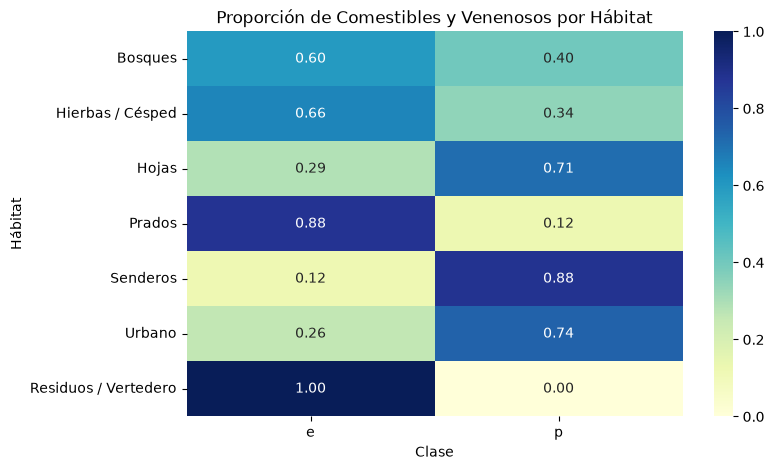

In [46]:
# Diccionario de traducción para mapear los códigos de hábitat a nombres claros en español
traduccion_habitat = {
    'g': 'Hierbas / Césped', 'l': 'Hojas', 'm': 'Prados',
    'p': 'Senderos', 'u': 'Urbano', 'w': 'Residuos / Vertedero', 'd': 'Bosques'
}
# Crear una tabla de contingencia normalizada por filas para obtener porcentajes relativos por hábitat
tabla = pd.crosstab(df['habitat'], df['class'], normalize='index')
# Traducir los índices de los hábitats sustituyendo los códigos por etiquetas legibles en español
tabla.index = tabla.index.map(traduccion_habitat)
# Definir las proporciones del lienzo para la visualización del mapa de calor
plt.figure(figsize=(8, 5))
# Graficar el mapa de calor incluyendo anotaciones numéricas con dos decimales (.2f) y paleta 'YlGnBu'
sns.heatmap(tabla, annot=True, cmap='YlGnBu', fmt='.2f')
# Establecer títulos y descripciones informativas de los ejes de la gráfica
plt.title('Proporción de Comestibles y Venenosos por Hábitat')
plt.ylabel('Hábitat')
plt.xlabel('Clase')
# Mostrar el gráfico completado en el notebook
plt.show()

Te dirá de forma muy visual si los hongos que crecen en determinados lugares (ej. senderos vs. bosques) o de cierta forma (ej. solitarios vs. numerosos) tienden a ser venenosos.

### Análisis Bivariado: Relación entre el Color del Sombrero y la Clase de Hongo
Se analiza la relación existente entre el color del sombrero (o copa) del hongo y su toxicidad. Mediante un diccionario de traducción al español se representan las categorías de forma clara sobre un gráfico de barras (`countplot`) agrupado según las clases objetivo.

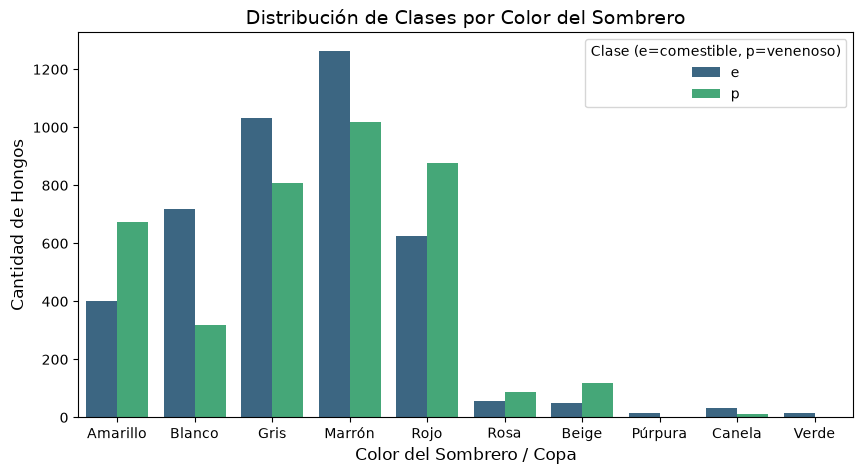

In [47]:
# Diccionario de traducción para convertir las abreviaturas de los colores del sombrero a español
traduccion_copa = {
    'n': 'Marrón', 'b': 'Beige', 'c': 'Canela', 'g': 'Gris',
    'r': 'Verde', 'p': 'Rosa', 'u': 'Púrpura', 'e': 'Rojo',
    'w': 'Blanco', 'y': 'Amarillo'
}
# Configurar el tamaño de la ventana gráfica para la visualización
plt.figure(figsize=(10, 5))
# Graficar las frecuencias aplicando la traducción directa sobre los datos del eje X
# Se utiliza la variable 'class' en el parámetro 'hue' con la paleta de colores 'viridis'
sns.countplot(x=df['cap-color'].map(traduccion_copa), hue=df['class'], palette='viridis')
# Asignar los nombres correspondientes en español a los ejes y al título del gráfico con sus respectivos tamaños de fuente
plt.xlabel('Color del Sombrero / Copa', fontsize=12)
plt.ylabel('Cantidad de Hongos', fontsize=12)
plt.title('Distribución de Clases por Color del Sombrero', fontsize=14)
# Incluir la leyenda indicando el significado de cada clase
plt.legend(title='Clase (e=comestible, p=venenoso)')
# Renderizar y desplegar la gráfica en el notebook
plt.show()

### Selección de Variables mediante Prueba de Chi-Cuadrado ($\chi^2$)
Con el fin de determinar de manera matemática qué variables categóricas tienen una relación estadísticamente significativa con la variable objetivo (`class`), se implementa una función que calcula el test de **Chi-cuadrado de independencia**. 

Para facilitar la visualización de los $p\text{-values}$ extremadamente pequeños, se aplica una transformación logarítmica ($-\log_{10}$), donde un valor resultante más alto representa una mayor fuerza de asociación estadística e importancia para el modelado.

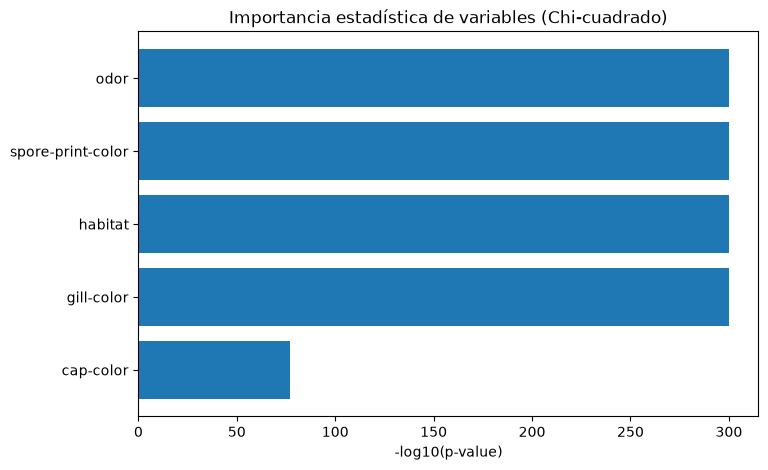

            variable       p_value       log_p
0               odor  0.000000e+00  300.000000
1  spore-print-color  0.000000e+00  300.000000
2            habitat  0.000000e+00  300.000000
4         gill-color  0.000000e+00  300.000000
3          cap-color  5.609094e-78   77.251107


In [48]:
# Definición de función para automatizar la prueba estadística de Chi-cuadrado
def chi_square_test(df, col, target='class'):
    # Generar la tabla de contingencia (frecuencias cruzadas) entre la variable de estudio y el target
    tabla = pd.crosstab(df[col], df[target])
    # Calcular el test de Chi-cuadrado. El segundo valor devuelto es el p-value (P)
    _, p, _, _ = chi2_contingency(tabla)
    # Se devuelve solo el p-value
    return p
# Lista con las variables categóricas preseleccionadas durante el EDA para evaluar su relevancia
variables = [
    'odor',
    'spore-print-color',
    'habitat',
    'cap-color',
    'gill-color'
]
# Construir un nuevo DataFrame aplicando la función a cada variable mediante una lista de comprensión
results = pd.DataFrame({
    "variable": variables,
    "p_value": [chi_square_test(df, col) for col in variables]
})
# Ordenar los resultados de menor a mayor p-value (las relaciones más significativas primero)
results = results.sort_values("p_value")
# Aplicar transformación logarítmica (-log10) para amplificar visualmente los p-values cercanos a cero
# Se manejan los ceros absolutos reemplazándolos por un valor ínfimo (1e-300) para evitar errores matemáticos
results["log_p"] = -np.log10(results["p_value"].replace(0, 1e-300))
# --- Configuración del Gráfico de Importancia Estadística ---
plt.figure(figsize=(8,5))
# Crear un gráfico de barras horizontales usando la métrica transformada logarítmicamente
plt.barh(results["variable"], results["log_p"])
# Configurar títulos y etiquetas informando sobre la escala de la transformación
plt.xlabel("-log10(p-value)")
plt.title("Importancia estadística de variables (Chi-cuadrado)")
# Invertir el eje Y para que la variable más importante/significativa aparezca en la parte superior
plt.gca().invert_yaxis()
# Desplegar el gráfico
plt.show()
# --- Salida en Texto ---
# Imprimir el DataFrame final con el resumen de métricas numéricas en la consola
print(results)

### Conclusiones de la Selección de Variables (Feature Selection)
Análisis e interpretación de los resultados numéricos obtenidos mediante la prueba de Chi-cuadrado. Se evalúa el nivel de significancia de cada variable predictora respecto a la comestibilidad.

> **Conclusiones clave:**
> * Las variables `odor`, `spore-print-color`, `habitat` y `gill-color` muestran un $p\text{-value}$ extremadamente cercano a 0, reflejando una dependencia estadística total con la variable objetivo.
> * La variable `cap-color` también cuenta con significancia estadística, aunque su fuerza de asociación es comparativamente menor.
> * El olor se consolida preliminarmente como uno de los factores biológicos más determinantes para la clasificación.

## Exportación del Dataset Preprocesado
Una vez completadas las fases de limpieza, tratamiento de nulos, eliminación de variables irrelevantes o sin varianza, y análisis exploratorio, se procede a crear el directorio correspondiente (si no existe) y exportar el DataFrame procesado a un archivo CSV. Esto asegura la persistencia de los datos limpios para las celdas o scripts posteriores del proyecto.

In [49]:
# Definir la ruta hacia la carpeta 'data' dentro del directorio raíz del proyecto
data_dir = BASE_DIR / "data"
# Crear la carpeta de datos de forma segura; 'exist_ok=True' evita que falle si la carpeta ya existe
data_dir.mkdir(exist_ok=True)
# Establecer la ruta y el nombre final del archivo comprimido o procesado (.csv)
clean_data_path = data_dir / "mushrooms_clean.csv"
# Exportar el DataFrame a la ruta definida sin incluir el índice automático de Pandas
df.to_csv(clean_data_path, index=False)
# Imprimir un mensaje informativo en la consola con la ruta absoluta donde se guardó el archivo
print(f"Dataset guardado en: {clean_data_path}")

Dataset guardado en: C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-project-classification-Grupo-1\data\mushrooms_clean.csv
